# Patterns of cell-cell communication and metabolic activities (scCellFie)

Previously we showed how Tensor-cell2cell can be used to [extract patterns of multiple modalities of cell-cell communication (CCC)](../Tensor-cell2cell-CTCA). Here we will show how our CTCA can be extended to couple CCC and intracellular metabolic activity. Here we use the tools [cell2cell](https://github.com/earmingol/cell2cell) and [scCellFie](https://sccellfie.readthedocs.io/) to predict CCC and the activity of metabolic tasks, respectively.

In this case, we use samples from cortical brain organoids across different time points, previously published by [Trujillo et al (2019)](https://doi.org/10.1016/j.stem.2019.08.002).

In [1]:
use_gpu = False

import tensorly as tl
if use_gpu:
    tl.set_backend('pytorch')

**Importing packages to use**

In [2]:
import cell2cell as c2c
import scanpy as sc
import sccellfie

import numpy as np
import pandas as pd

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

/Users/earmingol/miniforge3/envs/cell2cell/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/earmingol/miniforge3/envs/cell2cell/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/earmingol/miniforge3/envs/cell2cell/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn

In [3]:
import warnings
warnings.filterwarnings('ignore')

**IMPORTANT: In this notebook, the version 0.8.0 of cell2cell is used. Older versions do not implement the Coupled Tensor Component Analysis (CTCA).**

## 1 - Load Data

**Specify folders where the data is located, and where the outputs will be written:**

In [4]:
import os

data_folder = './data/'
directory = os.fsencode(data_folder)

output_folder = './results/scCellFie/'
os.makedirs(output_folder, exist_ok=True)

### RNA-seq data

A preprocessed version of the original paper [(Trujillo et al, 2019)](https://doi.org/10.1016/j.stem.2019.08.002) can be found [here](https://codeocean.com/capsule/9262293/tree/v1/data/preprocessed/annotated_seurat_norm_harmony_2022.h5ad)

In [5]:
rnaseq = sc.read_h5ad(data_folder + '/annotated_seurat_norm_harmony_2022.h5ad')

In [6]:
rnaseq = rnaseq.raw.to_adata()

In [7]:
rnaseq.obs.head(2)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.5,seurat_clusters,celltype,old.ident
Month-01_AAACCTGAGAATTGTG-1,Month-01,6417.0,2431,2.898551,11,11,Other,11
Month-01_AAACCTGAGCAACGGT-1,Month-01,8522.0,2464,2.663694,6,6,Progenitor,6


### Ligand-Receptor pairs

Different databases of ligand-receptor interactions could be used. We previously created a repository that includes many available DBs (https://github.com/LewisLabUCSD/Ligand-Receptor-Pairs). In this tutorial, we employ the ligand-receptor pairs from CellChat (https://doi.org/10.1038/s41467-021-21246-9), which includes multimeric protein complexes.

In [8]:
lr_pairs = pd.read_csv('https://raw.githubusercontent.com/LewisLabUCSD/Ligand-Receptor-Pairs/master/Human/Human-2020-Jin-LR-pairs.csv')
lr_pairs = lr_pairs.astype(str)

In [9]:
lr_pairs.head(2)

,interaction_name,pathway_name,ligand,receptor,agonist,antagonist,co_A_receptor,co_I_receptor,evidence,annotation,interaction_name_2,ligand_symbol,receptor_symbol,ligand_ensembl,receptor_ensembl,interaction_symbol,interaction_ensembl
0,TGFB1_TGFBR1_TGFBR2,TGFb,TGFB1,TGFbR1_R2,TGFb agonist,TGFb antagonist,nan,TGFb inhibition receptor,KEGG: hsa04350,Secreted Signaling,TGFB1 - (TGFBR1+TGFBR2),TGFB1,TGFBR1&TGFBR2,ENSG00000105329,ENSG00000106799&ENSG00000163513,TGFB1^TGFBR1&TGFBR2,ENSG00000105329^ENSG00000106799&ENSG00000163513
1,TGFB2_TGFBR1_TGFBR2,TGFb,TGFB2,TGFbR1_R2,TGFb agonist,TGFb antagonist,nan,TGFb inhibition receptor,KEGG: hsa04350,Secreted Signaling,TGFB2 - (TGFBR1+TGFBR2),TGFB2,TGFBR1&TGFBR2,ENSG00000092969,ENSG00000106799&ENSG00000163513,TGFB2^TGFBR1&TGFBR2,ENSG00000092969^ENSG00000106799&ENSG00000163513


In [10]:
# interaction columns:
int_columns = ('ligand_symbol', 'receptor_symbol')

## 2 - Data Preprocessing

### RNA-seq for CCC

**Organize data to create tensor**

First, define contexts

In [11]:
contexts = ['Month-01', 'Month-03', 'Month-06', 'Month-10']

**Generate list of RNA-seq data containing all contexts (time points)**

Here, we convert the single-cell expression levels into cell-type expression levels.
A basic context-wise preprocessing is performed here, keeping only genes that are expressed at least in 4 single cells, and cell types per context with at least 20 cells.

**Important:** A list of aggregated gene expression matrices must be used for building the 4D-communication tensor. Each of the gene expression matrices is for one of the contexts, following the same order as the previouslist (`contexts`).

The aggregation here corresponds to mean expression value across cells of each cell type. Other aggregation methods could be used by changing the parameter ```method='average'``` in the ```aggregate_single_cell()``` function. Additionally, other gene expression values could be passed, using other preprocessing approaches such as log(x+1) or batch correction methods.

In [12]:
rnaseq_matrices = []

for context in tqdm(contexts):
    meta_context = rnaseq.obs.loc[(rnaseq.obs['orig.ident'] == context) \
                                  & (rnaseq.obs['celltype'] != 'Other') & (rnaseq.obs['celltype'] != 'MC')]
    
    # Remove celltype per context that has few single cells
    min_sc_number = 20
    excluded_sc = []
    for idx, row in (meta_context.groupby(['celltype'])[['celltype']].count() >= min_sc_number).iterrows():
        if ~row['celltype']:
            excluded_sc.append(idx)
        
    meta_context = meta_context.loc[~meta_context['celltype'].isin(excluded_sc)]
    cells = list(meta_context.index)

    meta_context.index.name = 'barcode'
    tmp_data = rnaseq[cells]
    # Keep genes in each sample with at least 4 single cells expressing it
    sc.pp.filter_genes(tmp_data, min_cells=4)
    
    # Normalize and Log1p
    sc.pp.normalize_total(tmp_data, target_sum=1e6)
    sc.pp.log1p(tmp_data)

    # Aggregate gene expression of single cells into cell types
    exp_df = c2c.preprocessing.aggregate_single_cells(rnaseq_data=tmp_data.to_df(),
                                                      metadata=meta_context,
                                                      barcode_col='barcode',
                                                      celltype_col='celltype',
                                                      method='average',
                                                     )

    rnaseq_matrices.append(exp_df)

100%|█████████████████████████████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.33s/it]


`rnaseq_matrices` is the list we will use for building the tensor based on protein-based ligand-receptor pairs.

### LR pairs

Remove bidirectionality in the list of protein-based ligand-receptor pairs. That is, remove repeated interactions where both interactions are the same but in different order:

From this list:

| Ligand | Receptor |
| --- | --- |
| Protein A | Protein B |
| Protein B | Protein A |

We will have:

| Ligand | Receptor |
| --- | --- |
| Protein A | Protein B |

In [13]:
lr_pairs = c2c.preprocessing.ppi.remove_ppi_bidirectionality(ppi_data=lr_pairs, 
                                                             interaction_columns=int_columns
                                                             )

Removing bidirectionality of PPI network


In [14]:
lr_pairs.shape

(1988, 17)

**Generate a dictionary with function info for each LR pairs.**

Keys are ***LIGAND_NAME^RECEPTOR_NAME*** (this is the same nomenclature that will be used when building the protein-based 4D-communication tensor later), and values are the function in the annotation column in the dataframe containing ligand-receptor pairs. ***Other functional annotations of the LR pairs could be used if available.***

In [15]:
ppi_functions = dict()

for idx, row in lr_pairs.iterrows():
    ppi_functions[row['interaction_symbol']] = row['annotation']

## 3 - Predict metabolic activities with scCellFie

Here, the python tool **scCellFie** to predict metabolic activities based on the gene expression of enzymes that are part of a specific metabolic task, as indicated in [this tutorial](https://sccellfie.readthedocs.io/en/latest/notebooks/quick_start_human.html).

We only need the raw counts in the single-cell data to make the predictions, as scCellFie performs all necessary processing. However, to perform a smoothing based on neighbors, we will compute the neighbors based on the harmony components:

In [16]:
sc.pp.neighbors(rnaseq, use_rep='X_harmony')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [17]:
rnaseq

AnnData object with n_obs × n_vars = 15973 × 21042
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype', 'old.ident'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'neighbors'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

In [18]:
results = sccellfie.run_sccellfie_pipeline(rnaseq,
                                           organism='human',
                                           sccellfie_data_folder=None,
                                           n_counts_col='nCount_RNA', # Total counts per cell will be computed if left as None,
                                           process_by_group=False, # Whether to do the processing by cell groups
                                           groupby=None, # Column indicating cell groups if `process_by_group=True`
                                           neighbors_key='neighbors', # Neighbors information if precomputed. Otherwise, it will be computed here
                                           n_neighbors=10, # Number of neighbors to use
                                           batch_key=None, # there is no batch_key in this dataset
                                           threshold_key='sccellfie_threshold',  # This is for using the default database. If personalized thresholds are used, specificy column name
                                           smooth_cells=True, # Whether to perform gene expression smoothing before running the tool
                                           alpha=0.33, # Importance of neighbors' expression for the smoothing (0 to 1)
                                           chunk_size=5000, # Number of chunks to run the processing steps (helps with the memory)
                                           disable_pbar=False,
                                           save_folder=None, # In case results will be saved. If so, results will not be returned and should be loaded from the folder (see sccellfie.io.load_data function
                                           save_filename=None # Name for saving the files, otherwise a default name will be used
                                          )


==== scCellFie Pipeline: Initializing ====
Loading scCellFie database for organism: human

==== scCellFie Pipeline: Processing entire dataset ====

---- scCellFie Step: Preprocessing data ----

---- scCellFie Step: Preparing inputs ----
Gene names corrected to match database: 22
Shape of new adata object: (15973, 838)
Number of GPRs: 764
Shape of tasks by genes: (218, 838)
Shape of reactions by genes: (764, 838)
Shape of tasks by reactions: (218, 764)

---- scCellFie Step: Smoothing gene expression ----


Smoothing Expression: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.61it/s]



---- scCellFie Step: Computing gene scores ----

---- scCellFie Step: Computing reaction activity ----


Cell Rxn Activities: 100%|███████████████████████████████████████████████████| 15973/15973 [02:07<00:00, 125.10it/s]



---- scCellFie Step: Computing metabolic task activity ----
Removed 0 metabolic tasks with zeros across all cells.

==== scCellFie Pipeline: Processing completed successfully ====


The results can be found here:

In [19]:
results.keys()

dict_keys(['adata', 'gpr_rules', 'task_by_gene', 'rxn_by_gene', 'task_by_rxn', 'rxn_info', 'task_info', 'thresholds', 'organism'])

To access metabolic activities, we need to inspect `results['adata']`:

- The processed single-cell data is located in the AnnData object `results['adata']`.

- The reaction activities for each cell are located in the AnnData object `results['adata'].reactions`.

- The metabolic task activities for each cell are located in the AnnData object `results['adata'].metabolic_tasks`.

In [20]:
met_activities = results['adata'].metabolic_tasks.copy()

We will scale these activities with respect to the ranges previously computed across the [CZI CELLxGENE Human Cell Atlas](https://www.sccellfie.org/)

In [21]:
minmax = pd.read_csv('https://raw.githubusercontent.com/ventolab/sccellfie-website/refs/heads/main/data/CELLxGENEMetabolicTasksMinMax.csv', index_col=0)
minmax

,(R)-3-Hydroxybutanoate synthesis,3'-Phospho-5'-adenylyl sulfate synthesis,AMP salvage from adenine,ATP generation from glucose (hypoxic conditions) - glycolysis,ATP regeneration from glucose (normoxic conditions) - glycolysis + krebs cycle,Acetoacetate synthesis,Alanine degradation,Alanine synthesis,Arachidonate degradation,Arachidonate synthesis,...,Valine to succinyl-coA,Vesicle secretion,beta-Alanine degradation,beta-Alanine synthesis,cis-vaccenic acid degradation,cis-vaccenic acid synthesis,gamma-Linolenate degradation,gamma-Linolenate synthesis,glyco-cholate synthesis,tauro-cholate synthesis
single_cell_min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
single_cell_max,7.419829,11.795217,20.651447,13.613079,4.979552,8.038148,3.030361,7.951063,1.752682,4.296328,...,6.424888,2.780753,2.980583,6.203485,2.161476,4.050148,2.341566,7.578767,2.982760,2.982760
cell_type_min,0.041299,0.000000,0.000000,0.033310,0.024252,0.023852,0.028060,0.025760,0.000000,0.021624,...,0.000000,0.000000,0.025981,0.029364,0.000000,0.013848,0.000000,0.000000,0.000000,0.000000
cell_type_max,4.403184,4.105401,5.187688,7.840590,3.159272,4.670686,1.874831,4.480565,0.854841,2.594763,...,1.313472,0.798270,1.899791,3.463882,1.151658,2.225383,1.263210,1.716187,0.941299,0.941299


We divide each task value by the max value found across the human cell atlas, so we scale them between 0 and 1:

In [22]:
met_activities.X = np.clip(met_activities.X / minmax.loc['single_cell_max', :].values.reshape(-1), a_min=0., a_max=1.0)

Similar to the CCC part where we prepared the gene expression data, here we convert the single-cell metabolic activities into cell-type activity levels.

A basic context-wise preprocessing is performed here, keeping only cell types per context with at least 20 cells.

In [23]:
met_matrices = []

for context in tqdm(contexts):
    meta_context = rnaseq.obs.loc[(rnaseq.obs['orig.ident'] == context) \
                                  & (rnaseq.obs['celltype'] != 'Other') & (rnaseq.obs['celltype'] != 'MC')]
    
    # Remove celltype per context that has few single cells
    min_sc_number = 20
    excluded_sc = []
    for idx, row in (meta_context.groupby(['celltype'])[['celltype']].count() >= min_sc_number).iterrows():
        if ~row['celltype']:
            excluded_sc.append(idx)
        
    meta_context = meta_context.loc[~meta_context['celltype'].isin(excluded_sc)]
    cells = list(meta_context.index)

    meta_context.index.name = 'barcode'
    tmp_data = met_activities[cells]

    # Aggregate gene expression of single cells into cell types, using the trimean
    exp_df = sccellfie.expression.aggregation.agg_expression_cells(met_activities,
                                                                   groupby='celltype', 
                                                                   agg_func='trimean')

    met_matrices.append(exp_df)

100%|█████████████████████████████████████████████████████████████████████████████████| 4/4 [00:04<00:00,  1.23s/it]


In [24]:
met_matrices[0]

Task,(R)-3-Hydroxybutanoate synthesis,3'-Phospho-5'-adenylyl sulfate synthesis,AMP salvage from adenine,ATP generation from glucose (hypoxic conditions) - glycolysis,ATP regeneration from glucose (normoxic conditions) - glycolysis + krebs cycle,Acetoacetate synthesis,Alanine degradation,Alanine synthesis,Arachidonate degradation,Arachidonate synthesis,...,Valine to succinyl-coA,Vesicle secretion,beta-Alanine degradation,beta-Alanine synthesis,cis-vaccenic acid degradation,cis-vaccenic acid synthesis,gamma-Linolenate degradation,gamma-Linolenate synthesis,glyco-cholate synthesis,tauro-cholate synthesis
GABAergic,0.257290,0.070321,0.016719,0.248574,0.289472,0.257290,0.316788,0.251865,0.122373,0.317457,...,0.024489,0.088211,0.349128,0.258951,0.183256,0.262169,0.175722,0.041018,0.017065,0.017065
Glia,0.228816,0.017635,0.033727,0.215604,0.267410,0.227830,0.336807,0.231558,0.161978,0.301874,...,0.033127,0.068634,0.364833,0.233392,0.210315,0.257721,0.202597,0.049065,0.034382,0.034382
Glutamatergic,0.185345,0.064322,0.025364,0.173935,0.232887,0.184854,0.271598,0.184064,0.127847,0.251595,...,0.024005,0.070838,0.304126,0.193836,0.175435,0.211203,0.169420,0.043661,0.019224,0.019224
IP,0.222547,0.052597,0.027519,0.213665,0.270883,0.222173,0.310499,0.222034,0.138435,0.299648,...,0.024196,0.081357,0.348271,0.224283,0.204476,0.246714,0.195585,0.040729,0.022202,0.022202
MC,0.176754,0.014631,0.020480,0.168017,0.204469,0.175424,0.274017,0.175904,0.115840,0.236990,...,0.029954,0.058975,0.300923,0.181178,0.175457,0.199442,0.165586,0.043496,0.018289,0.018289
Other,0.136290,0.022540,0.034058,0.128478,0.162129,0.136080,0.209196,0.134473,0.086839,0.178832,...,0.031152,0.055257,0.232028,0.137534,0.123759,0.149276,0.118593,0.025574,0.017805,0.017805
Progenitor,0.142688,0.011824,0.060387,0.132497,0.168674,0.142371,0.215409,0.141622,0.105195,0.191222,...,0.040749,0.068754,0.249974,0.149202,0.142666,0.151951,0.138825,0.012511,0.032817,0.032817


## 4 - Build Tensors

### Build 4D-Communication Tensor

Here we use as input the list of gene expression matrices (`rnaseq_matrices`) that were aggregated into a cell-type granularity. This list contains the expression matrices of all samples/contexts.

The following functions perform all the steps to build a 4D-communication tensor:

![4dtensor](../figures/4d-tensor.png)



The parameter ```communication_score``` indicates the scoring function to use.


```how='outer_cells'``` considers only LR pairs that are present in all contexts, while all cell types in the whole dataset are kept, regardless they appear only in one or a few contexts.

```complex_sep='&'``` is used to specify that the list of ligand-receptor pairs contains protein complexes and that subunits are separated by '&'. If the list does not have complexes, use ```complex_sep=None``` instead.

In [25]:
tensor_lr = c2c.tensor.InteractionTensor(rnaseq_matrices=rnaseq_matrices,
                                         ppi_data=lr_pairs,
                                         context_names=contexts,
                                         how='outer_cells',
                                         complex_sep='&',
                                         interaction_columns=int_columns,
                                         communication_score='expression_gmean',
                                         order_labels=['Contexts', 'Protein LRIs', 'Sender Cells', 'Receiver Cells'],
                                         device='cuda' if use_gpu else 'cpu'
                                        )

Getting expression values for protein complexes
Building tensor for the provided context


In [26]:
tensor_lr.tensor.shape

(4, 422, 5, 5)

### Build 3D Metabolic Task Activity Tensor

To build our 3D tensor with dimensions as contexts, receiver cells, and metabolic tasks, we need to make sure that all cell types in the 4D tensor are present in each matrix (for those missing we will assign a NaN value).

We get the list of cell types:

In [27]:
celltypes = tensor_lr.order_names[-1]

Then we reindex all matrices with metabolic activities (this will generate missing rows (index), and fill them with NaNs):

In [28]:
met_activities_nan = [met.reindex(index=celltypes) for met in met_matrices]

Now we can use these scCellFie outputs directly to generate our 3D metabolic activity tensor. First we generate just the tensor containing the values using tensorly:

In [29]:
tensor_3d = tl.tensor(met_activities_nan)
tensor_3d.shape

(4, 5, 218)

We then obtain the name of metabolic task present in the data:

In [30]:
met_names = met_activities_nan[0].columns.tolist()

Now we take this tensor to generate an `InteractionTensor` object using cell2cell:

In [31]:
tensor_met = c2c.tensor.PreBuiltTensor(tensor_3d, 
                                       order_names=[contexts, celltypes, met_names],
                                       order_labels=['Contexts', 'Receiver Cells', 'Metabolic Tasks']
                                      )

In [32]:
tensor_met.tensor.shape

(4, 5, 218)

## 5 - Generate coupled tensors  

After constructing our 4D communication tensor and 3D metabolic task activity tensor, we can create a `CoupledInteractionTensor` object in Tensor-cell2cell v2. This object will later be used to perform CTCA.  

The key step here is to define which dimensions should be coupled between the tensors. In this example:  

- **Context dimensions** are coupled directly, since they are identical across both tensors.  
- **Cell type dimension (in the metabolic task tensor)** can be coupled either with the **sender** or **receiver** dimension (in the communication tensor):  
  - **Couple to sender:** Metabolic task activity is aligned with the cells producing the ligands of each LR pair. This suggests that the metabolic state of sender cells could influence or coordinate with their ability to produce signaling molecules.  
  - **Couple to receiver:** Metabolic task activity is aligned with the cells receiving the signal through the receptor. This suggests that metabolic programs may be regulated downstream of the receptors, capturing how cell-cell communication drives metabolic changes in the receiving cells.  

In this tutorial, we choose the **second option (coupling to the receiver)**. This means we focus on metabolic task activity that is potentially triggered by LR interactions within the CCC program.  

Concretely, the **context dimension** corresponds to `dim 0` in both tensors, while the **receiver cell dimension** is `dim 3` in the 4D communication tensor and `dim 2` in the 3D metabolic task tensor.  


In [33]:
coupled_tensor = c2c.tensor.CoupledInteractionTensor(tensor1=tensor_lr,
                                                     tensor2=tensor_met,
                                                     tensor1_name='cell2cell',
                                                     tensor2_name='scCellFie',
                                                      # Below we specify how dims of tensor1 are coupled with dims of tensor2
                                                     mode_mapping={'shared' : [(0,0), (3,1)]}
                                                    )

We can observe that this object includes both tensors simultaneously.

In [34]:
coupled_tensor.shape

((4, 422, 5, 5), (4, 5, 218))

## 6 - Run Analysis

### Perform tensor factorization

Next, we apply a non-negative canonical coupled component analysis (CTCA). Briefly, this tensor decomposition identifies a low-rank tensor (here, a rank of 10) for each modality's tensor that better approximates each original tensor. These low-rank tensors can be represented as the sum of a set of rank-1 tensors (10 of them in this case). Each rank-1 tensor represents a factor in the decomposition and can be further represented as the outer product of n vectors, where n represents the number of tensor dimensions. Each vector represents one of the n tensor dimensions for that factor and its values, corresponding to individual elements in each dimension, represent the factor loadings. 

In the CTCA, we have vectors that are shared between the coupled tensors (here contexts and receiver cells), while we have other vectors that are private for each modality (LR pair and sender cells for the 4D communication tensor; metabolic tasks for the 3D metabolic activity tensor). The loadings shared between both tensors behave exactly the same in both modalities, representing that we are capturing LR pairs and metabolic tasks from each modality that present similar trends in each factor. If each tensor was decomposed separately with the standard TCA in Tensor-cell2cell v1, we would not ensure that the key LR pair and metabolic tasks for each factor would behave the same, as this could lead to loadings for the context and receiver cells with different behaviors between modalities.

To illustrate how performing the CTCA for identifying LR pairs acting coordinated with metabolic activities, we skipped the Elbow Analysis, which can be found in our [previous tutorial for protein- and metabolite-based LR pairs](../Tensor-cell2cell-CTCA/). Instead, we run the factorization using a manual number of 10 factors:

In [35]:
coupled_tensor.compute_tensor_factorization(rank=10, # This is just for illustrative purposes - to keep a low number of factors
                                            init='svd',
                                            random_state=888,
                                            runs=1, tol=1e-8, n_iter_max=500 # Robust version of tensor decomposition
                                           )

## 7 - Results

### Metadata

**Generate a list containing metadata for each tensor order/dimension - Later used for coloring factor plots**

This is a list containing metadata for each dimension of the tensor (contexts, LR pairs, sender cells, receiver cells). Each metadata corresponds to a dataframe with info of each element in the respective dimension.

We start with the protein-based tensor.

In [36]:
meta_tf = c2c.tensor.generate_tensor_metadata(interaction_tensor=tensor_lr,
                                              metadata_dicts=[None, ppi_functions, None, None],
                                              fill_with_order_elements=True
                                             )

We continue with the metabolic activity tensor. We can find metabolic tasks metadata in `results['task_info']`:

In [37]:
results['task_info'].head()

,Task,System,Subsystem
0,(R)-3-Hydroxybutanoate synthesis,CARBOHYDRATES METABOLISM,KETOGENESIS
1,3'-Phospho-5'-adenylyl sulfate synthesis,NUCLEOTIDE METABOLISM,COFACTOR
2,AMP salvage from adenine,NUCLEOTIDE METABOLISM,SALVAGE
3,ATP generation from glucose (hypoxic condition...,ENERGY METABOLISM,ATP GENERATION
4,ATP regeneration from glucose (normoxic condit...,ENERGY METABOLISM,ATP GENERATION


Here we will use categories at the System level:

In [38]:
task_mapper = results['task_info'].set_index('Task')['System'].to_dict()

In [39]:
met_functions = {task: task_mapper[task] for task in tensor_met.order_names[2]}

In [40]:
meta_tf2 = c2c.tensor.generate_tensor_metadata(interaction_tensor=tensor_met,
                                              metadata_dicts=[None, None, met_functions],
                                              fill_with_order_elements=True
                                             )

**Generate unified metadata for CTCA results**

By using the metadata generated separately for each tensor, we generate a new metadata that incorporates metadata for the shared and private dimensions between both modalities.

In [41]:
new_meta_tf = coupled_tensor.reorder_metadata(meta_tf, meta_tf2)

### Plot factor loadings

After performing the CTCA, a set of loadings is obtained in a factor-specific way, for each tensor. These loadings provide details of what elements of each dimension are important within each factor. Here we plot first the loadings for the shared dimensions, followed by the private dimensions of the first and second tensor (LR pairs and Metabolic Tasks, respectively).

We generate the order of LR pairs and metabolic tasks given their categories:

In [42]:
lr_order = meta_tf[1].sort_values(['Category', 'Element'])['Element'].values.tolist()
met_order = meta_tf2[2].sort_values(['Category', 'Element'])['Element'].values.tolist()

And color palettes for each of the dimensions:

In [43]:
# Color palettes for each of the coupled tensor dimensions, ordered as order_sorting list below
cmaps = ['viridis', 'tab20', 'tab20', 'Dark2', 'tab20']

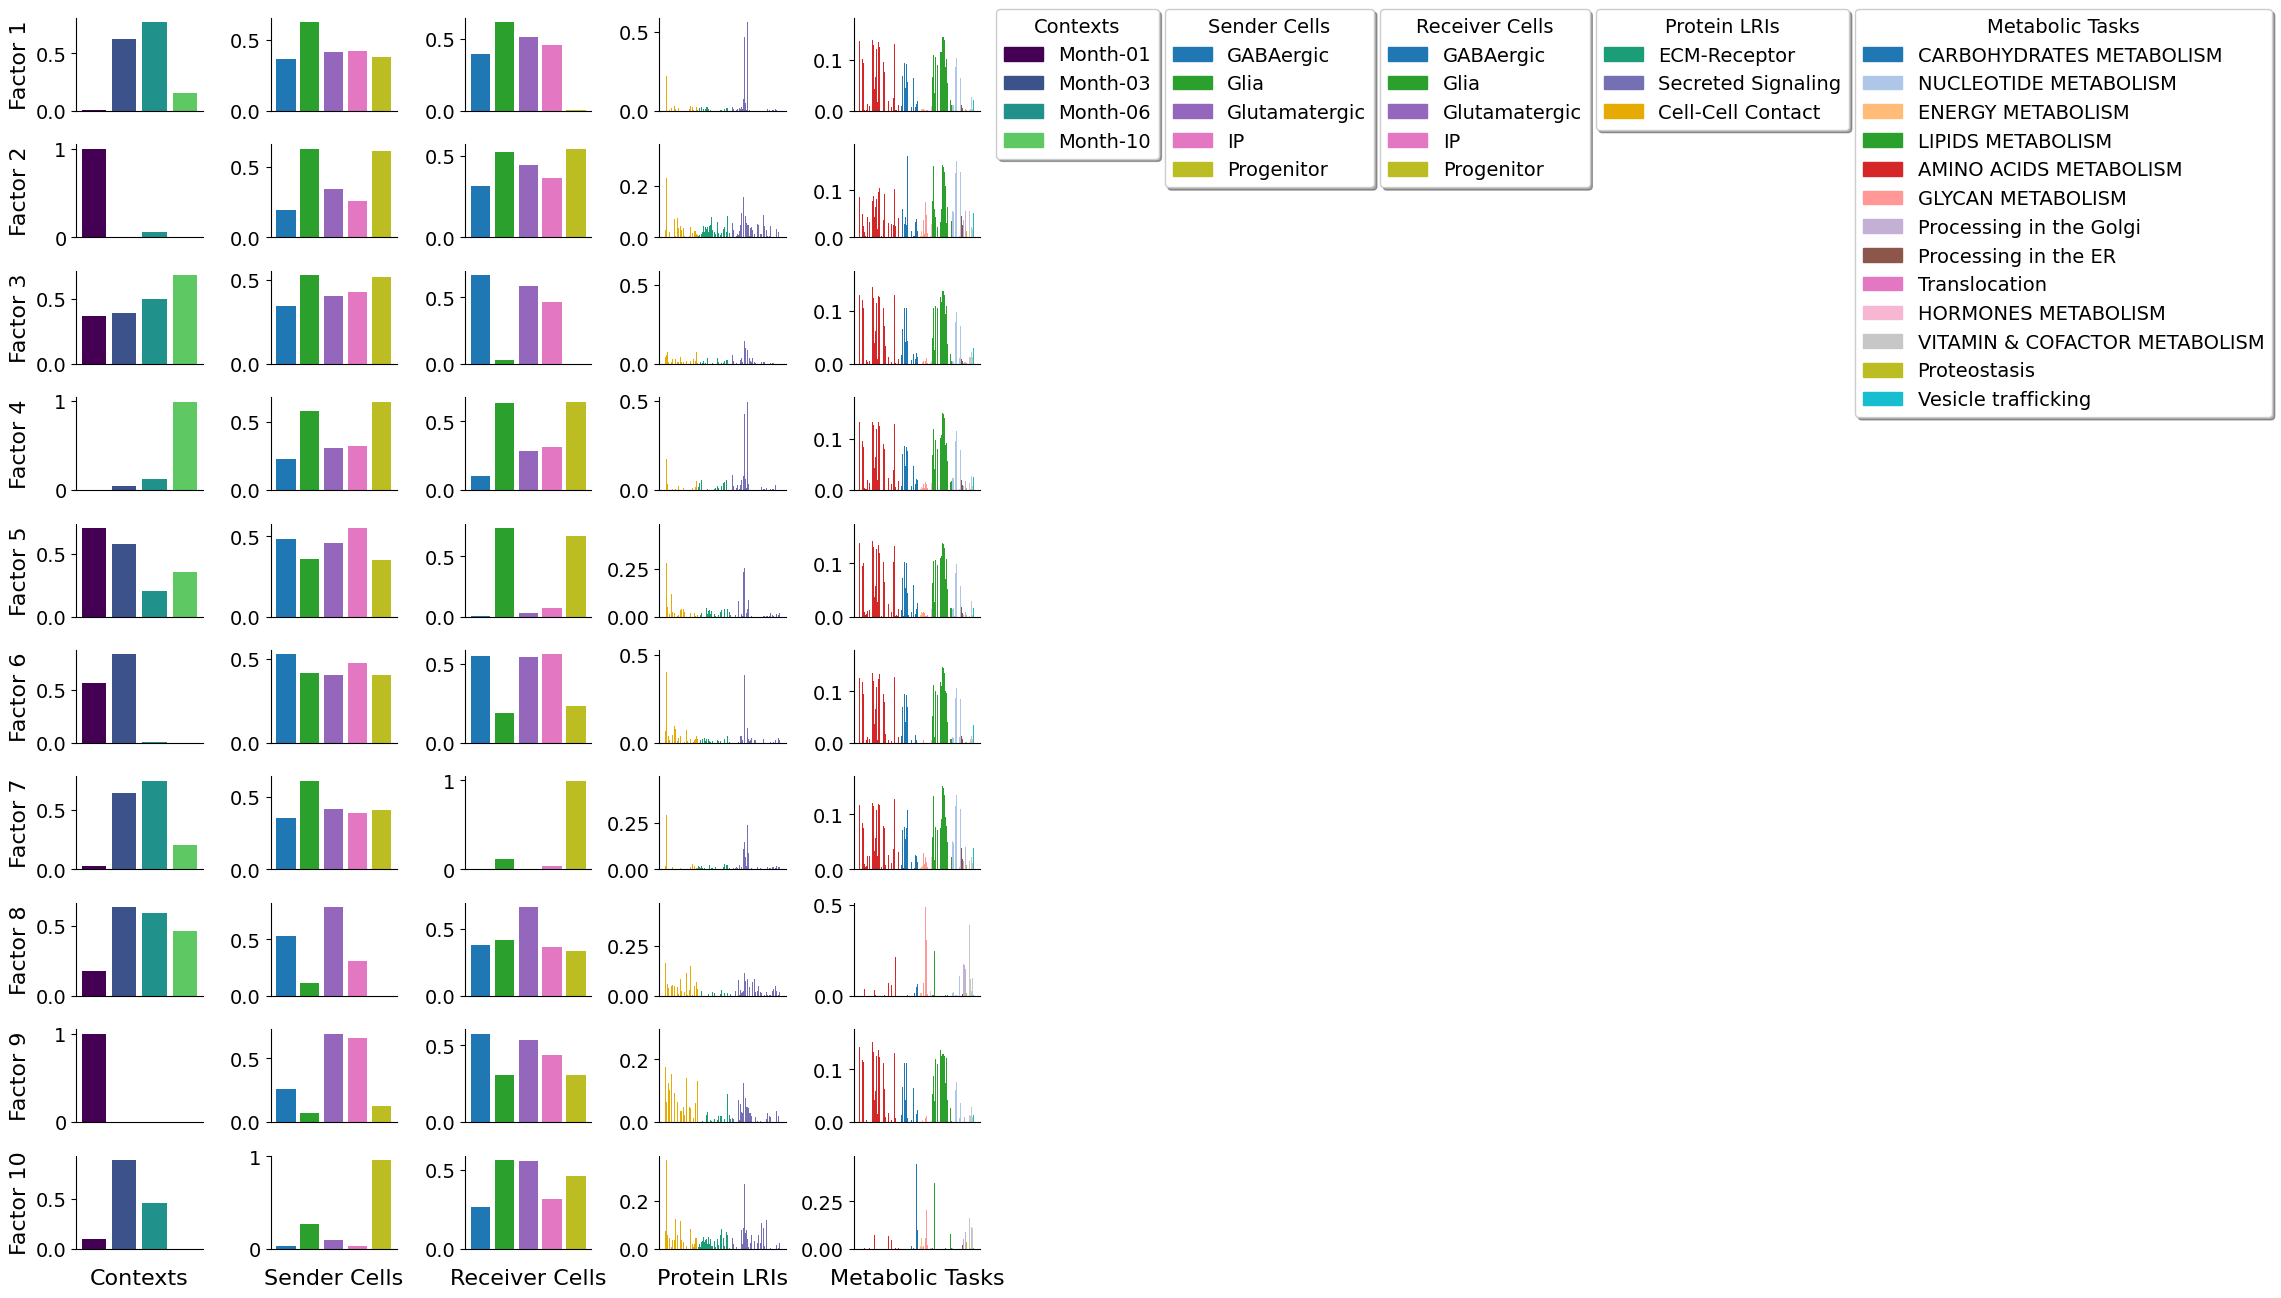

In [44]:
factors, axes = c2c.plotting.tensor_factors_plot(interaction_tensor=coupled_tensor,
                                                 metadata=new_meta_tf,
                                                 sample_col='Element',
                                                 group_col='Category',
                                                 meta_cmaps=cmaps,
                                                 # Order of dimensions
                                                 order_sorting=['Contexts', 'Sender Cells', 'Receiver Cells',
                                                                'Protein LRIs', 'Metabolic Tasks'
                                                               ],
                                                 # Order of elements
                                                 reorder_elements={'Protein LRIs' : lr_order,
                                                                   'Metabolic Tasks': met_order},
                                                 fontsize=14,
                                                 filename=output_folder + 'Tensor-Factorization.pdf'
                                                )

Each factor represents a context-dependent communication pattern. In this visualization, each row is a factor and each column is a tensor dimension in that factor (Shared dimensions: contexts and receiver-cells; Private dimensions: LR pairs, sender-cells, and metabolic tasks). 

The loadings represent the contribution of each element to that pattern, and their combinations between all dimensions represent the overall pattern. For example, in Factor 4, the identified communication pattern occurs in late stages, increasing across time, where glial cells and progenitors play a major role as sender and as receivers. Then we can identify the top LR pairs and metabolic tasks contributing from cognate modalities. Thus, we can say that the receptors of these LR pairs act in coordination with the metabolic tasks in the receiver cells.

### Top LR pairs and metabolic tasks

**Top-10 LR pairs**

In [45]:
for i in range(coupled_tensor.rank):
    print(coupled_tensor.get_top_factor_elements('Protein LRIs', 'Factor {}'.format(i+1), 10))
    print('')

PTN^PTPRZ1     0.557280
MDK^PTPRZ1     0.465805
PTN^NCL        0.428744
MDK^NCL        0.302474
CD99^CD99      0.220685
PTN^SDC3       0.133680
CDH2^CDH2      0.123069
NCAM1^NCAM1    0.104220
MDK^LRP1       0.098684
PTN^SDC1       0.090120
Name: Factor 1, dtype: float64

CDH2^CDH2          0.341753
MDK^NCL            0.266094
MDK^SDC2           0.255992
CD99^CD99          0.228306
GAS6^AXL           0.178054
PTN^NCL            0.176211
MDK^ITGA6&ITGB1    0.156021
PTN^SDC2           0.152977
MDK^LRP1           0.146969
WNT2B^FZD1&LRP6    0.136120
Name: Factor 2, dtype: float64

MDK^NCL          0.562104
PTN^NCL          0.470131
CDH2^CDH2        0.333121
NCAM1^NCAM1      0.230836
CADM1^CADM1      0.198455
MDK^LRP1         0.172793
MDK^PTPRZ1       0.142228
SEMA6A^PLXNA4    0.106818
NAMPT^INSR       0.099436
MPZL1^MPZL1      0.095037
Name: Factor 3, dtype: float64

PTN^PTPRZ1     0.494842
MDK^PTPRZ1     0.424226
PTN^NCL        0.330179
PTN^SDC3       0.255665
MDK^NCL        0.238550
CDH2

**Top 10 Metabolic Tasks**

In [46]:
for i in range(coupled_tensor.rank):
    print(coupled_tensor.get_top_factor_elements('Metabolic Tasks', 'Factor {}'.format(i+1), 10))
    print('')

Sphingomyelin synthesis                0.173427
Ceramide synthesis                     0.171588
Proline degradation                    0.151911
Ornithine degradation                  0.151333
beta-Alanine degradation               0.149608
Valine degradation                     0.149231
Phosphatidyl-choline synthesis         0.145805
Phosphatidyl-ethanolamine synthesis    0.145060
Phosphatidyl-serine synthesis          0.144230
Threonine degradation                  0.140467
Name: Factor 1, dtype: float64

Phosphatidyl-inositol synthesis                 0.188760
Synthesis of inositol                           0.178827
Synthesis of spermidine from ornithine          0.174557
Glucuronate synthesis (via inositol)            0.174342
Guanosine triphosphate synthesis (GTP)          0.171565
Deoxyguanosine triphosphate synthesis (dGTP)    0.162078
Phosphatidyl-choline synthesis                  0.162003
Sphingomyelin synthesis                         0.157309
Phosphatidyl-ethanolamine synthe

### Export Loadings

***THESE VALUES CAN BE USED FOR DOWNSTREAM ANALYSES***

In [47]:
coupled_tensor.export_factor_loadings(output_folder + 'Coupled-Loadings.xlsx')

Coupled tensor factor loadings saved to ./results/scCellFie/Coupled-Loadings.xlsx


## 8 - Downstream Analyses

### Generate factor-specific networks

We can generate factor-specific communication networks connecting sender-to-receiver cells.

In [48]:
networks = c2c.analysis.tensor_downstream.get_factor_specific_ccc_networks(coupled_tensor.factors, 
                                                                           sender_label='Sender Cells',
                                                                           receiver_label='Receiver Cells')

**Generate matrix of cell-cell pairs by factors**

In [49]:
network_by_factors = c2c.analysis.tensor_downstream.flatten_factor_ccc_networks(networks, orderby='receivers')

**Select cell-cell pairs with high potential of interaction**

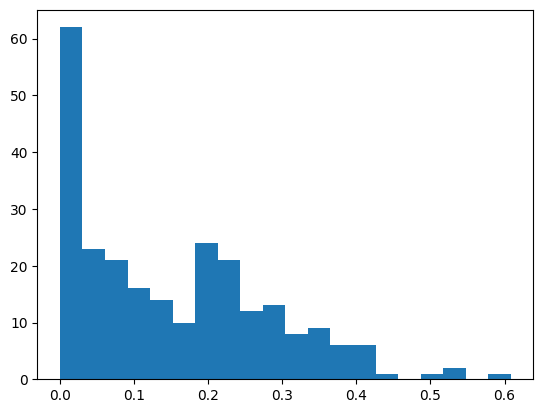

In [50]:
_ = plt.hist(network_by_factors.values.flatten(), bins = 20)

In [51]:
# To consider only cell pairs with high potential to interact in each factor
cci_threshold = 0.2

**Visualize networks of factors with significant differences between groups**

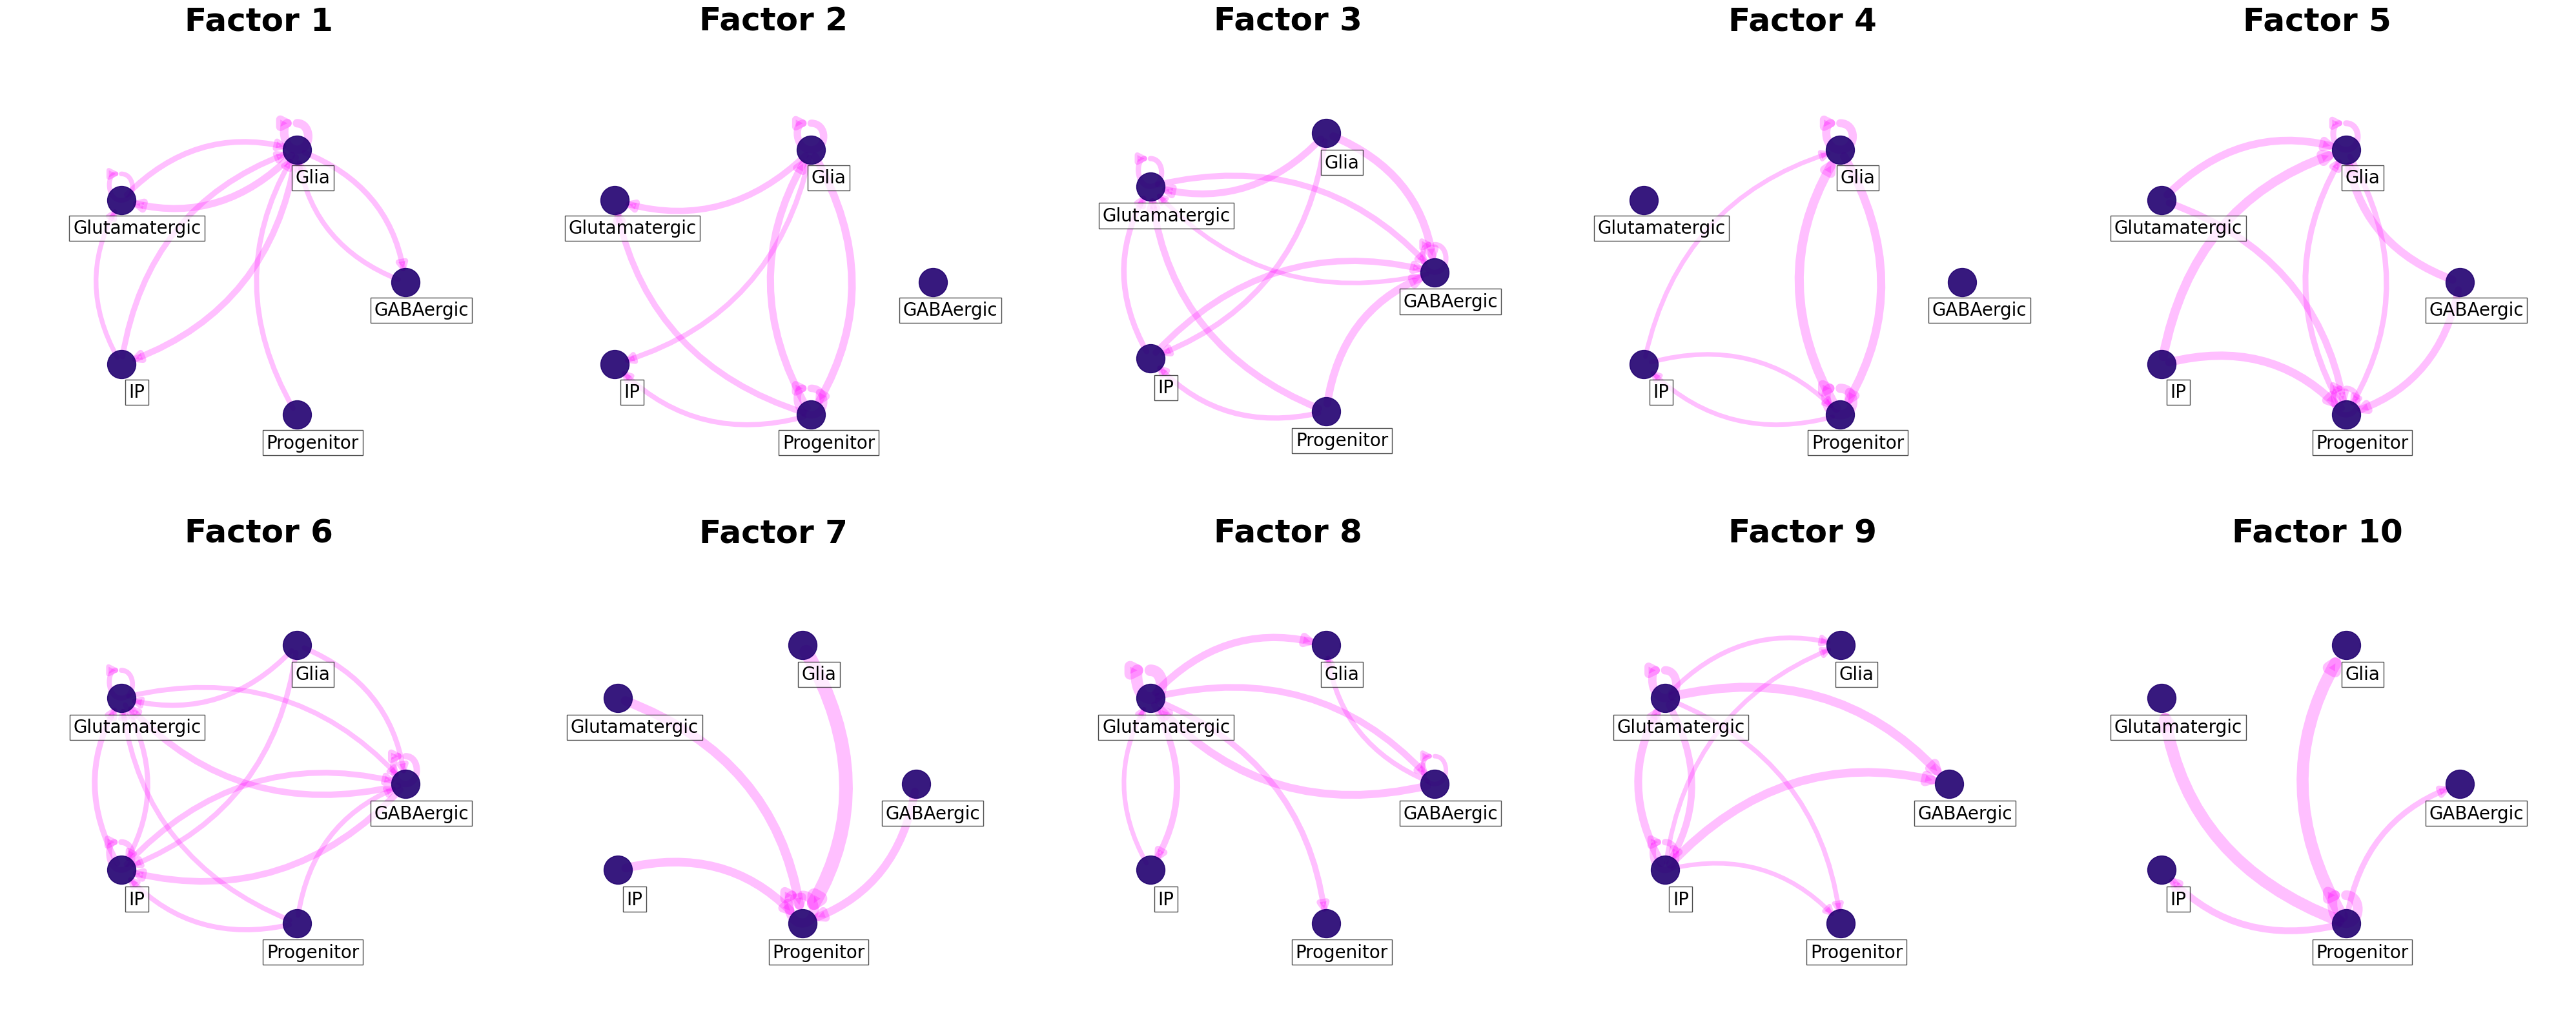

In [52]:
net_fig, net_ax = c2c.plotting.ccc_networks_plot(coupled_tensor.factors,
                                                 included_factors=None,
                                                 ccc_threshold=cci_threshold, # Only important communication
                                                 nrows=2,
                                                 panel_size=(8, 8),
                                                 network_layout='circular',
                                                 filename=output_folder + 'Networks.pdf'
                                                )

### Clustermaps


Similarly, we can visualize the contribution of each dimension element across factors by plotting their loadings

In [53]:
factor_sorted = ['Factor {}'.format(f) for f in range(1, coupled_tensor.rank+1)]

**Cluster cell-cell pairs by their potential across factors**

Here we display the outer product between the sender and receiver cell dimensions, which are the value governing the factor-specific networks above.

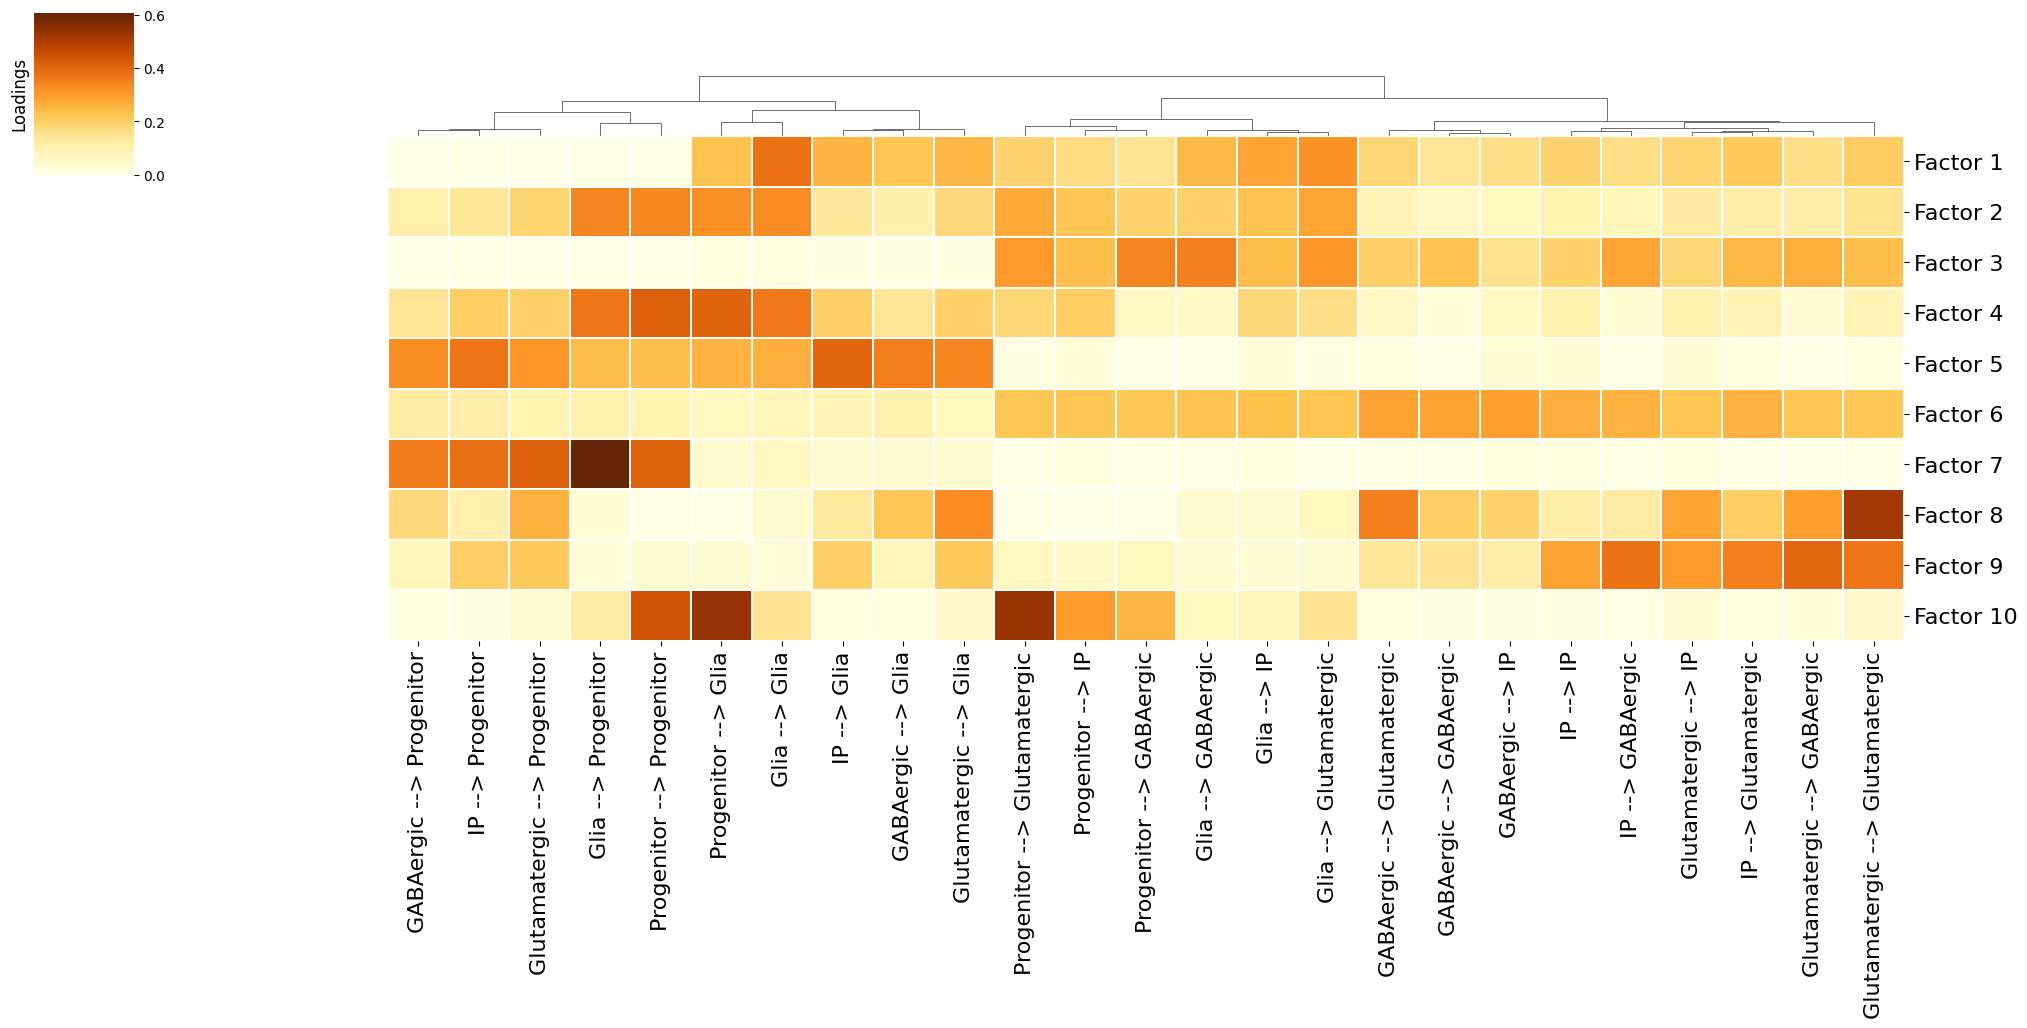

In [54]:
cci_cm = c2c.plotting.loading_clustermap(network_by_factors[factor_sorted],
                                         use_zscore=False, 
                                         loading_threshold=cci_threshold, # To consider relevant CCIs
                                         figsize=(20, 9),
                                         tick_fontsize=16,
                                         cmap='YlOrBr',
                                         filename=output_folder + 'Clustermap-Factor-specific-CCI.pdf',
                                         row_cluster=False
                                        )

**Cluster LR pairs by their importance across factors**

We can plot the key LR pairs from the CCC modality and TFs from the TF activity modality. First we identify what could represent a high loading given their separate distributions.

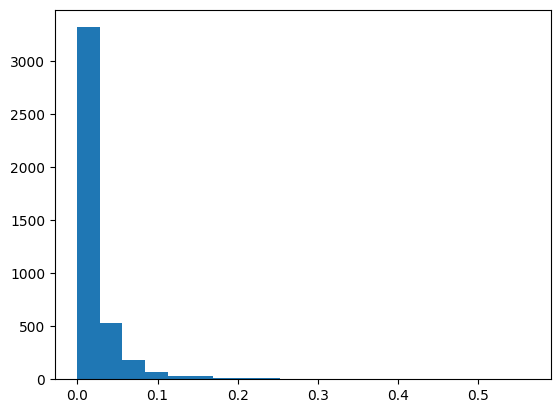

In [55]:
_ = plt.hist(coupled_tensor.factors['Protein LRIs'].values.flatten(), bins = 20)

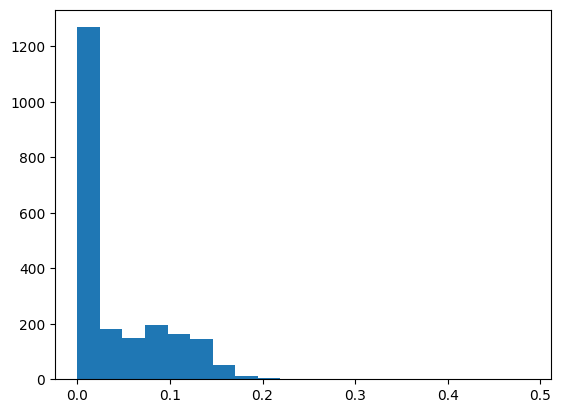

In [56]:
_ = plt.hist(coupled_tensor.factors['Metabolic Tasks'].values.flatten(), bins = 20)

And set and arbitrary threshold to filter out those that have *low loadings*

In [57]:
# To consider only most relevant LR pairs
lr_threshold = 0.15
met_threshold = 0.15

Since we have loadings from different modalities, we want to visualize them in a comparable way, so we normalize each of them by their maximum value in each case.

In [58]:
df1 = coupled_tensor.factors['Protein LRIs'].copy()
df1 = df1[(df1.T > lr_threshold).any()]
df1 = (df1 / df1.max())

df2 = coupled_tensor.factors['Metabolic Tasks'].copy()
df2 = df2[(df2.T > met_threshold).any()]
df2 = (df2 / df2.max())

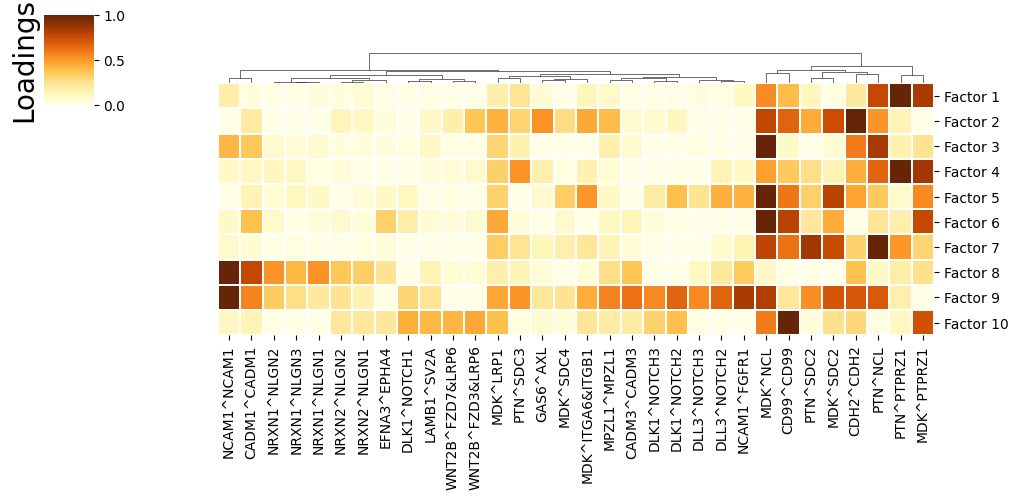

In [59]:
lr_cm = c2c.plotting.loading_clustermap(df1,
                                        loading_threshold=lr_threshold, # To consider only top LRs
                                        use_zscore=False,
                                        figsize=(10, 5),
                                        cbar_fontsize=20,
                                        tick_fontsize=10,
                                        cmap='YlOrBr',
                                        filename=output_folder + 'Clustermap-Factor-specific-ProtLRs.pdf',
                                        row_cluster=False
                                       )

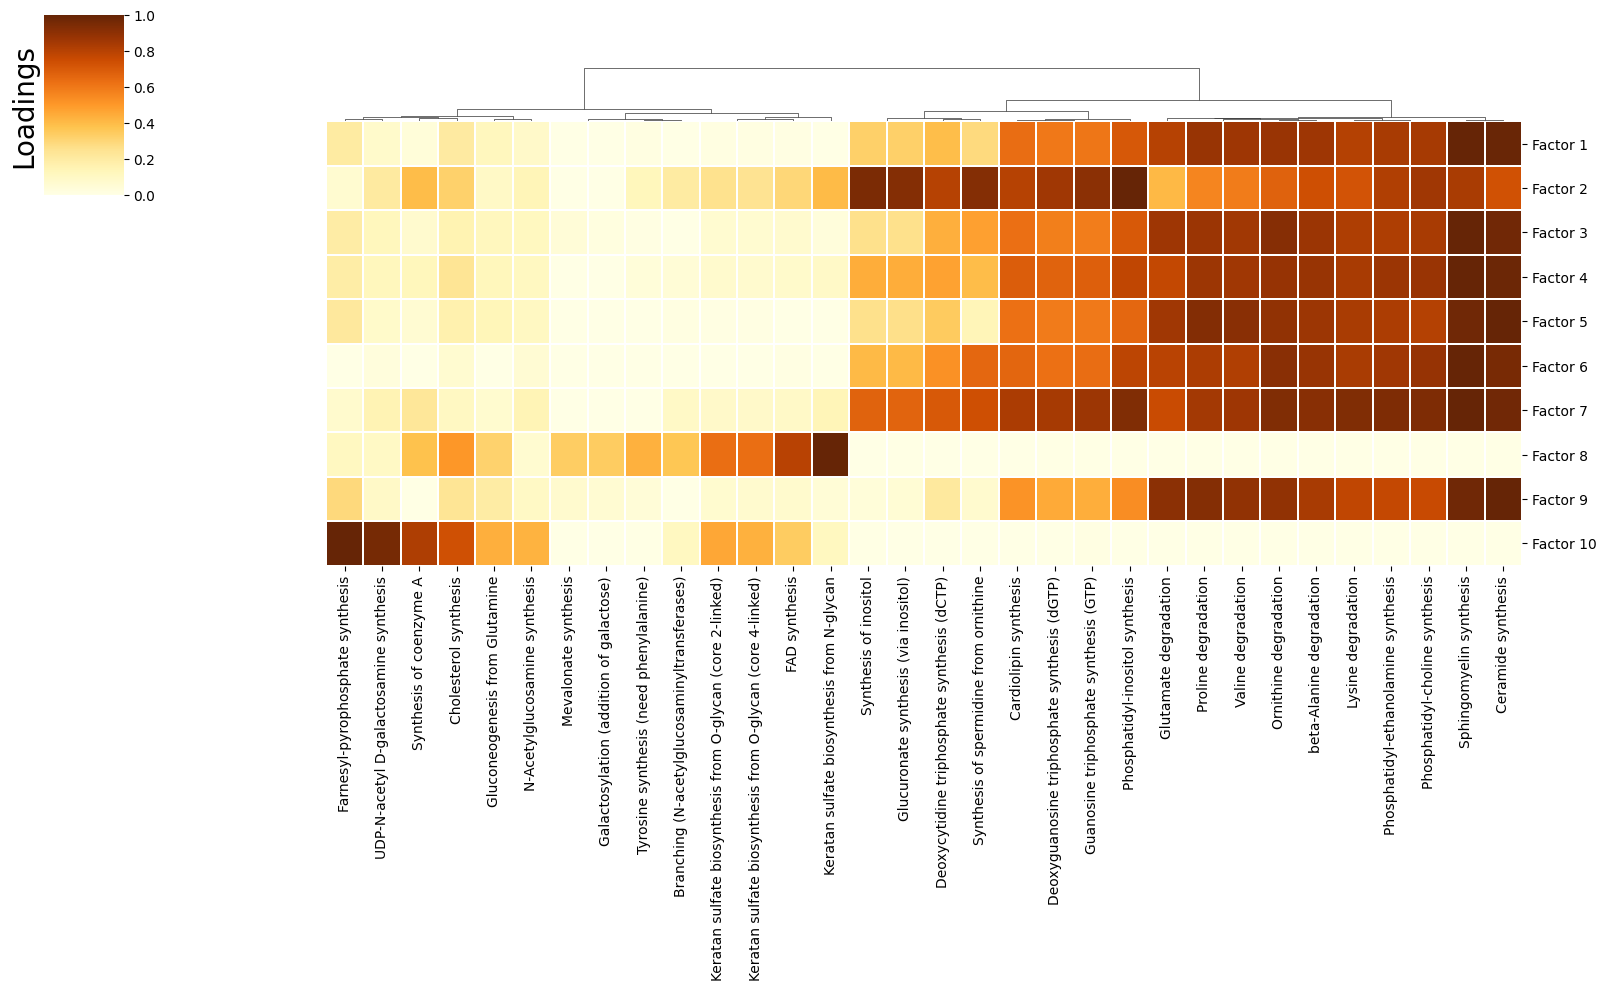

In [63]:
lr_cm = c2c.plotting.loading_clustermap(df2,
                                        loading_threshold=met_threshold, # To consider only top LRs
                                        use_zscore=False,
                                        figsize=(16, 10),
                                        cbar_fontsize=20,
                                        tick_fontsize=10,
                                        cmap='YlOrBr',
                                        filename=output_folder + 'Clustermap-Factor-specific-MetabolicTasks.pdf',
                                        row_cluster=False
                                       )

Given that we max-scaled them, we can also put them together in an unified plot

In [61]:
df = pd.concat([df1, df2])

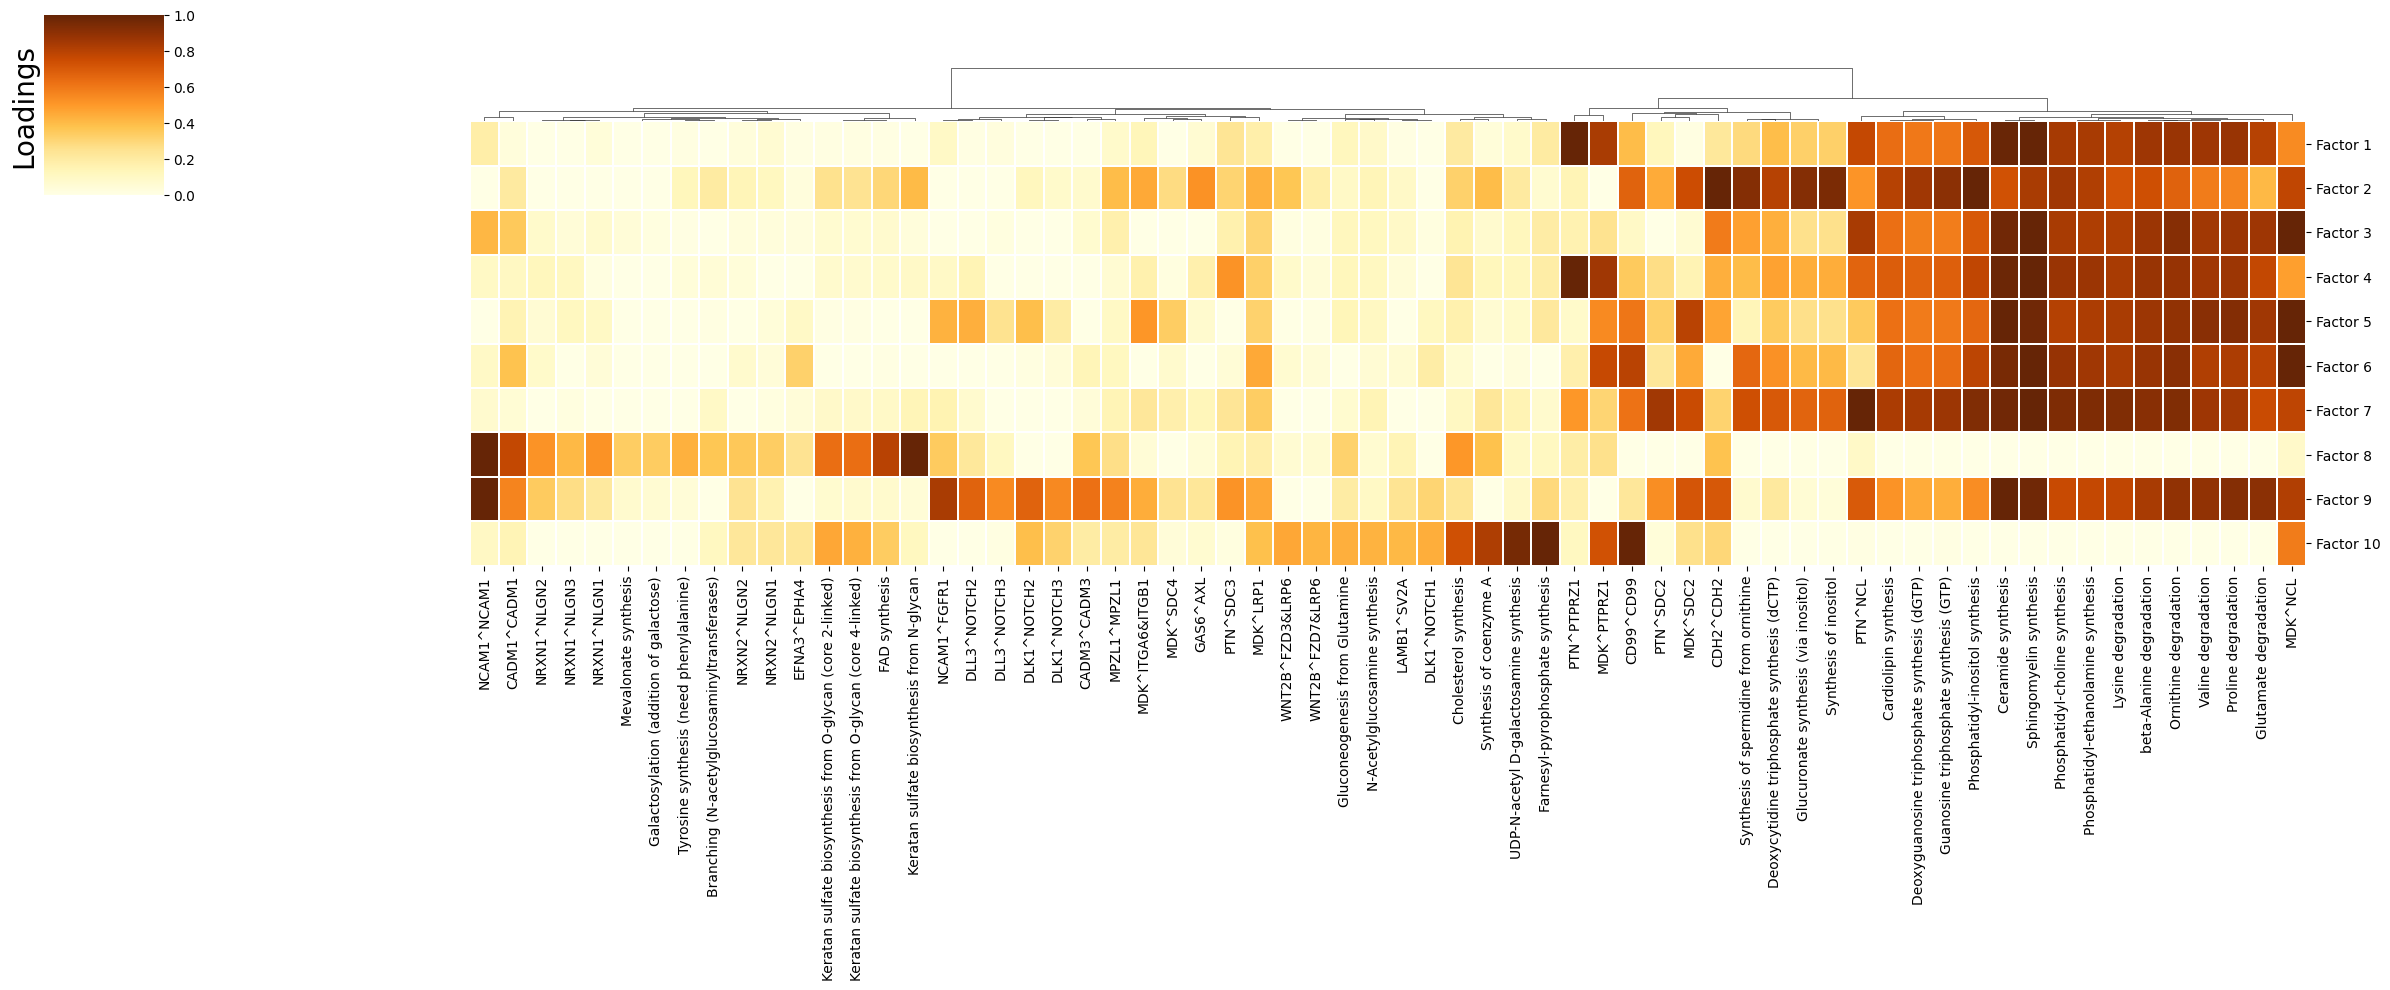

In [64]:
lr_cm = c2c.plotting.loading_clustermap(df,
                                        loading_threshold=0.1, # To consider only top LRs and TFs
                                        use_zscore=False,
                                        figsize=(24, 10),
                                        cbar_fontsize=20,
                                        tick_fontsize=10,
                                        cmap='YlOrBr',
                                        filename=output_folder + 'Clustermap-Factor-specific-LR-MetTasks.pdf',
                                        row_cluster=False
                                       )